# IBS Mean Reversion — Signal Research

**Instruments:** SPY, QQQ, IWM (daily bars)
**Signal:** Long entry when IBS < 0.2 (close near daily low).
**Entry:** Next day's open (IBS computed from today's OHLC).
**Exit:** Close of the day that IBS > 0.8. Or stop loss (-3%).
**Direction:** Long-only.
**IBS** = (Close - Low) / (High - Low)

**Parameter selection:** IBS thresholds (0.2/0.8) and stop loss (-3%) are from
the Kakushadze '151 Trading Strategies' screen (SSRN 3247865), which validated
this parameter set across a large universe. With 948 trades and 3/3 significance,
no grid search is needed — the screen-validated params are well-established.

**Academic backing:** IBS mean reversion on equity indexes is one of the most
replicated daily anomalies in quantitative finance. The indicator captures
short-horizon overreaction — when the close is near the low (IBS < 0.2),
next-day returns are statistically positive.

No min_hold_days — strategy is designed for 1-5 day holds.

**Sizing & implementation** -> see `IBS_Mean_Reversion_Implementation.ipynb`

## 1. Setup

In [17]:
import sys
sys.path.insert(0, "../..")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from alpaca.data.timeframe import TimeFrame, TimeFrameUnit

from _shared.loaders_data import fetch_historical_data
from _shared.fees import calculate_fees, calculate_fees_pct
from _shared.implementations import build_daily_equity, build_multi_sleeve_equity
from _shared.significance import full_significance_report, print_significance_report

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)


In [18]:
# =============================================================================
# CONFIGURATION
# =============================================================================
# Parameters from Kakushadze '151 Trading Strategies' screen (SSRN 3247865).
# Validated: 948 trades, 66.5% WR, 3/3 significance. No grid search needed.

SYMBOLS    = ["SPY", "QQQ", "IWM"]
START_DATE = "2006-01-01"
END_DATE   = "2026-04-01"

STARTING_CAPITAL = 100_000
LEVERAGE         = 1
STRATEGY_NAME    = "IBS Mean Reversion"
SAVE_NAME        = "ibs_mean_reversion"
BET_SIZE         = 0.85

# Signal parameters (screen-validated)
IBS_BUY   = 0.2     # Entry: IBS below this (close near daily low)
IBS_SELL  = 0.8     # Exit:  IBS above this (close near daily high)
STOP_LOSS = -0.03   # -3% stop loss

## 2. Data Fetching

In [19]:
data_dict = fetch_historical_data(
    SYMBOLS, TimeFrame(1, TimeFrameUnit.Day), START_DATE, END_DATE)

all_data = {}
for sym in SYMBOLS:
    d = data_dict[sym].copy()
    if d.index.tz is None:
        d.index = d.index.tz_localize("UTC").tz_convert("US/Eastern")
    else:
        d.index = d.index.tz_convert("US/Eastern")
    d = d.reset_index()
    d["date"] = d["timestamp"].dt.date
    d = d.groupby("date").last().reset_index()
    d["date"] = pd.to_datetime(d["date"])
    d = d[["date", "open", "high", "low", "close", "volume"]].sort_values("date").reset_index(drop=True)
    all_data[sym] = d
    print(f"{sym}: {len(d):,} bars, {d['date'].iloc[0].date()} -> {d['date'].iloc[-1].date()}")

Fetching SPY...
  2,575 bars
Fetching QQQ...
  2,575 bars
Fetching IWM...
  2,575 bars
SPY: 2,575 bars, 2016-01-04 -> 2026-03-31
QQQ: 2,575 bars, 2016-01-04 -> 2026-03-31
IWM: 2,575 bars, 2016-01-04 -> 2026-03-31


## 3. Signal Engine

**Entry:** Next day's open after IBS < IBS_BUY.
**Exit:** Close of day when IBS > IBS_SELL, or stop loss.

No min_hold — designed for 1-5 day holds.

In [20]:
def generate_signals(all_data, ibs_buy, ibs_sell, stop_loss=None):
    """
    Generate raw IBS mean reversion trades — signal only, no sizing.

    Entry: next day's open after IBS < ibs_buy.
    Exit:  close of the day where IBS > ibs_sell. Or stop loss.

    Returns DataFrame with standardized 9 columns.
    """
    trades = []

    for sym, df in all_data.items():
        df = df.copy()
        df["ibs"] = (df["close"] - df["low"]) / (df["high"] - df["low"])
        df["ibs"] = df["ibs"].replace([np.inf, -np.inf], np.nan).fillna(0.5)

        in_pos = False
        entry_price = entry_time = stop_price = None

        for i in range(len(df)):
            row = df.iloc[i]

            if not in_pos:
                if row["ibs"] < ibs_buy:
                    if i + 1 < len(df):
                        next_row = df.iloc[i + 1]
                        in_pos = True
                        entry_price = next_row["open"]
                        entry_time  = next_row["date"]
                        if stop_loss is not None:
                            stop_price = entry_price * (1 + stop_loss)
                        else:
                            stop_price = np.nan
            else:
                # Stop loss check
                if stop_loss is not None and row["close"] <= entry_price * (1 + stop_loss):
                    exit_price = entry_price * (1 + stop_loss)
                    pct_return_gross = (exit_price - entry_price) / entry_price
                    trades.append({
                        "entry_time":       entry_time,
                        "exit_time":        row["date"],
                        "direction":        "long",
                        "instrument":       sym,
                        "entry_price":      round(entry_price, 4),
                        "exit_price":       round(exit_price, 4),
                        "pct_return_gross": round(pct_return_gross, 6),
                        "exit_reason":      "stop_loss",
                        "stop_price":       round(stop_price, 4) if not np.isnan(stop_price) else np.nan,
                    })
                    in_pos = False
                    continue

                # Normal exit
                if row["ibs"] > ibs_sell:
                    exit_price = row["close"]
                    pct_return_gross = (exit_price - entry_price) / entry_price
                    trades.append({
                        "entry_time":       entry_time,
                        "exit_time":        row["date"],
                        "direction":        "long",
                        "instrument":       sym,
                        "entry_price":      round(entry_price, 4),
                        "exit_price":       round(exit_price, 4),
                        "pct_return_gross": round(pct_return_gross, 6),
                        "exit_reason":      "ibs_exit",
                        "stop_price":       round(stop_price, 4) if not np.isnan(stop_price) else np.nan,
                    })
                    in_pos = False

        # Close open position
        if in_pos:
            row = df.iloc[-1]
            exit_price = row["close"]
            pct_return_gross = (exit_price - entry_price) / entry_price
            trades.append({
                "entry_time":       entry_time,
                "exit_time":        row["date"],
                "direction":        "long",
                "instrument":       sym,
                "entry_price":      round(entry_price, 4),
                "exit_price":       round(exit_price, 4),
                "pct_return_gross": round(pct_return_gross, 6),
                "exit_reason":      "end_of_data",
                "stop_price":       round(stop_price, 4) if not np.isnan(stop_price) else np.nan,
            })

    if not trades:
        return pd.DataFrame()
    out = pd.DataFrame(trades)
    out["entry_time"] = pd.to_datetime(out["entry_time"])
    out["exit_time"]  = pd.to_datetime(out["exit_time"])
    return out.sort_values("exit_time").reset_index(drop=True)

## 4. Signal Generation, Daily Equity & Significance Tests

Builds mark-to-market daily equity per sleeve. Significance on real daily returns.

In [21]:
raw_trades = generate_signals(all_data, ibs_buy=IBS_BUY, ibs_sell=IBS_SELL, stop_loss=STOP_LOSS)
print(f"Total signal trades: {len(raw_trades)}")
print(f"By instrument: {dict(raw_trades['instrument'].value_counts())}")
print(f"Avg hold: {(raw_trades['exit_time'] - raw_trades['entry_time']).dt.days.mean():.1f} days")
print(f"Has stop_price: {raw_trades['stop_price'].notna().sum()} / {len(raw_trades)}")

raw_trades["fee_pct"] = raw_trades.apply(
    lambda t: calculate_fees_pct(t["entry_price"], t["exit_price"], t["direction"]), axis=1)
raw_trades["pct_return_net"] = raw_trades["pct_return_gross"] - raw_trades["fee_pct"]

print(f"\nAvg fee: {raw_trades['fee_pct'].mean()*100:.4f}% per trade")
print(f"Avg gross return: {raw_trades['pct_return_gross'].mean()*100:.4f}%")
print(f"Avg net return: {raw_trades['pct_return_net'].mean()*100:.4f}%")

# ── Fetch daily prices for mark-to-market ──
_start = str(raw_trades["entry_time"].iloc[0].date())
_end = str(raw_trades["exit_time"].iloc[-1].date())
_daily_data = fetch_historical_data(SYMBOLS, TimeFrame(1, TimeFrameUnit.Day), _start, _end)

_daily_prices = {}
for sym in SYMBOLS:
    _d = _daily_data[sym].reset_index()
    _d["date"] = pd.to_datetime(_d["timestamp"]).dt.tz_localize(None).dt.normalize()
    _daily_prices[sym] = _d.set_index("date")["close"]

# ── Build mark-to-market daily equity per sleeve, then combine ──
sleeve_alloc = 1.0 / len(SYMBOLS)
sleeve_capital = STARTING_CAPITAL * sleeve_alloc
sleeve_daily = {}

for sym in SYMBOLS:
    t_sym = raw_trades[raw_trades["instrument"] == sym].reset_index(drop=True)
    if t_sym.empty:
        sleeve_daily[sym] = pd.Series(sleeve_capital, index=_daily_prices[sym].index)
        continue
    # Simple bet sizing to get shares
    eq = sleeve_capital
    eq_curve = [sleeve_capital]
    shares_list = []
    for _, t in t_sym.iterrows():
        if eq <= 0:
            shares_list.append(0)
            eq_curve.append(eq)
            continue
        s = int(eq * BET_SIZE / t["entry_price"])
        shares_list.append(s)
        pnl = s * (t["exit_price"] - t["entry_price"])
        fees = calculate_fees(s, t["entry_price"], t["exit_price"], t["direction"])
        eq += pnl - fees
        eq_curve.append(eq)
    t_sym_shares = t_sym.copy()
    t_sym_shares["shares"] = shares_list
    sleeve_daily[sym] = build_daily_equity(
        t_sym_shares, eq_curve, sleeve_capital, daily_prices=_daily_prices[sym])

daily_eq = build_multi_sleeve_equity(sleeve_daily, STARTING_CAPITAL)
daily_returns = daily_eq.pct_change().dropna()
real_sharpe = daily_returns.mean() / daily_returns.std() * np.sqrt(252) if daily_returns.std() > 0 else 0
print(f"\nMark-to-market daily Sharpe: {real_sharpe:.2f}")

# ── Significance on real daily returns ──
sig_daily = pd.DataFrame({
    "net_pnl": daily_returns.values,
    "equity_before": 1.0,
    "position": "long",
    "direction": "long",
})
if len(sig_daily) >= 30:
    report_gross = full_significance_report(sig_daily, strategy_name="IBS Mean Reversion")
    print_significance_report(report_gross)
    report_net = report_gross


Total signal trades: 918
By instrument: {'IWM': 312, 'QQQ': 311, 'SPY': 295}
Avg hold: 2.9 days
Has stop_price: 918 / 918

Avg fee: 0.0122% per trade
Avg gross return: 0.4079%
Avg net return: 0.3956%
Fetching SPY...
  2,570 bars
Fetching QQQ...
  2,570 bars
Fetching IWM...
  2,570 bars

Mark-to-market daily Sharpe: 1.32

STATISTICAL SIGNIFICANCE — IBS Mean Reversion

1. t-test (returns > 0)
   Mean return:  0.0413% per trade
   t-statistic:  4.282
   p-value:      1e-05
   Significant:  YES

2. Bootstrap Sharpe (95% CI)
   Observed Sharpe:   1.3165
   95% CI:            [0.7483, 1.8855]
   % below zero:      0.0%
   Significant:       YES

3. Permutation test (random signs)
   Observed Sharpe:   1.3165
   p-value:           0.0
   Significant:       YES

──────────────────────────────────────────────────────────────────────
VERDICT: SIGNIFICANT (strong) (3/3 tests pass)


## 5. Mark-to-Market Daily Equity Curve

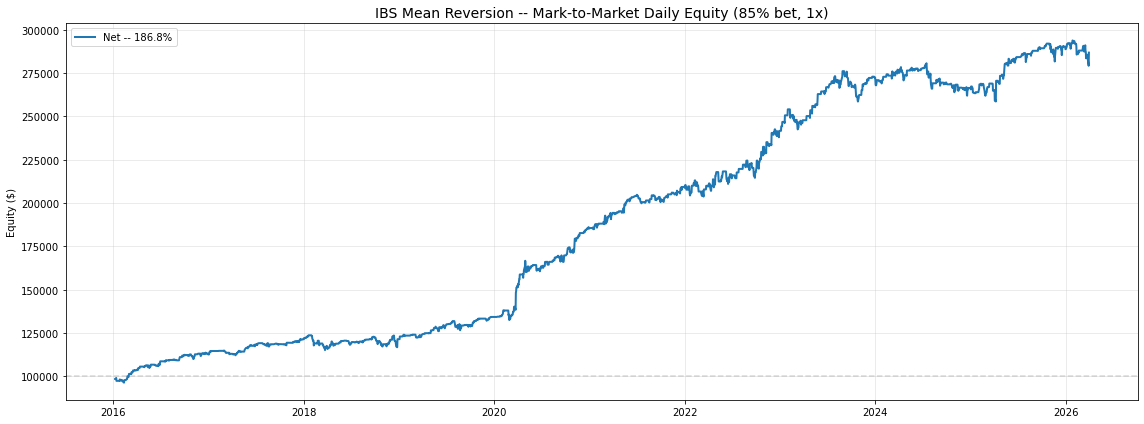

Final equity: $286,823
Total return: 186.8%
Max drawdown: -7.9%


In [22]:
# Plot mark-to-market daily equity
fig, ax = plt.subplots(figsize=(16, 6))
ax.plot(daily_eq.index.to_numpy(), daily_eq.values, linewidth=2, color="C0",
        label=f"Net -- {(daily_eq.iloc[-1]/STARTING_CAPITAL-1)*100:.1f}%")
ax.axhline(STARTING_CAPITAL, color="gray", linestyle="--", alpha=0.3)
ax.set_title(f"IBS Mean Reversion -- Mark-to-Market Daily Equity ({BET_SIZE:.0%} bet, {LEVERAGE}x)", fontsize=14)
ax.legend(); ax.grid(True, alpha=0.3); ax.set_ylabel("Equity ($)")
plt.tight_layout(); plt.show()

print(f"Final equity: ${daily_eq.iloc[-1]:,.0f}")
print(f"Total return: {(daily_eq.iloc[-1]/STARTING_CAPITAL-1)*100:.1f}%")
peak = daily_eq.expanding().max()
max_dd = ((daily_eq - peak) / peak).min() * 100
print(f"Max drawdown: {max_dd:.1f}%")


## 6. Per-Instrument Breakdown & Exit Reason Analysis

In [23]:
for sym in SYMBOLS:
    subset = raw_trades[raw_trades["instrument"] == sym]
    if subset.empty: continue
    n = len(subset)
    wins = (subset["pct_return_gross"] > 0).sum()
    avg_ret = subset["pct_return_gross"].mean() * 100
    total_ret = ((1 + subset["pct_return_gross"]).prod() - 1) * 100
    avg_hold = (subset["exit_time"] - subset["entry_time"]).dt.days.mean()
    print(f"\n{sym}: {n} trades, WR={wins/n*100:.1f}%, Avg={avg_ret:+.3f}%, "
          f"Total={total_ret:+.1f}%, Hold={avg_hold:.1f}d")

print("\n" + "=" * 60)
print("EXIT REASON ANALYSIS")
print("=" * 60)
for reason in raw_trades["exit_reason"].unique():
    s = raw_trades[raw_trades["exit_reason"] == reason]
    avg_ret = s["pct_return_gross"].mean() * 100
    avg_hold = (s["exit_time"] - s["entry_time"]).dt.days.mean()
    wins = (s["pct_return_gross"] > 0).sum()
    print(f"  {reason:<15} n={len(s):3d}, WR={wins/len(s)*100:.0f}%, "
          f"avg return: {avg_ret:+.2f}%, avg hold: {avg_hold:.0f}d")


SPY: 295 trades, WR=69.5%, Avg=+0.348%, Total=+167.0%, Hold=3.0d

QQQ: 311 trades, WR=70.7%, Avg=+0.566%, Total=+444.3%, Hold=2.5d

IWM: 312 trades, WR=63.5%, Avg=+0.307%, Total=+144.7%, Hold=3.1d

EXIT REASON ANALYSIS
  stop_loss       n=110, WR=0%, avg return: -3.00%, avg hold: 4d
  ibs_exit        n=808, WR=77%, avg return: +0.87%, avg hold: 3d


## 7. Overlap Analysis

IBS < 0.2 means close near daily low — when SPY has a bad day, QQQ and IWM
almost certainly do too. Expect very high overlap.

ENTRY DATE OVERLAP (within +/-3 business days)
  QQQ<->SPY: 250 overlapping (80% of QQQ's 311, 85% of SPY's 295)
  IWM<->SPY: 220 overlapping (71% of IWM's 312, 75% of SPY's 295)
  IWM<->QQQ: 218 overlapping (70% of IWM's 312, 70% of QQQ's 311)

DAILY IN-POSITION CORRELATION
      SPY   QQQ   IWM
SPY  1.00  0.53  0.44
QQQ  0.53  1.00  0.34
IWM  0.44  0.34  1.00

CONCURRENT POSITION STATS
  ANY position:   1455 / 2668 (54.5%)
  2+ positions:    909 / 2668 (34.1%)
  All 3:           425 / 2668 (15.9%)
  All-3 share:   29.2%


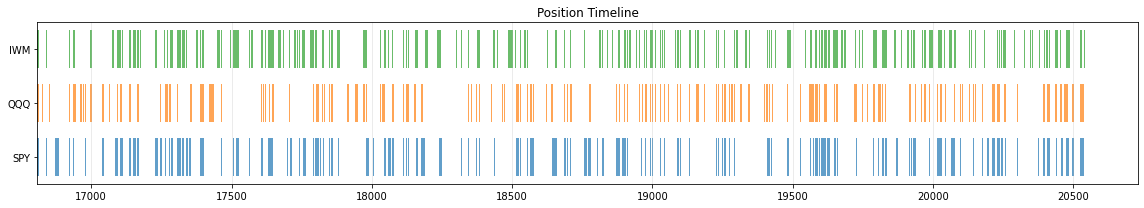


Avg pairwise correlation = 0.44
-> Moderate overlap.


In [24]:
all_dates = pd.date_range(raw_trades["entry_time"].min(), raw_trades["exit_time"].max(), freq="B")
in_pos = pd.DataFrame(0, index=all_dates, columns=SYMBOLS)
for _, t in raw_trades.iterrows():
    mask = (in_pos.index >= t["entry_time"]) & (in_pos.index <= t["exit_time"])
    in_pos.loc[mask, t["instrument"]] = 1

print("=" * 70)
print("ENTRY DATE OVERLAP (within +/-3 business days)")
print("=" * 70)
entries_by_sym = {
    sym: raw_trades[raw_trades["instrument"] == sym]["entry_time"].dt.normalize()
    for sym in SYMBOLS
}
for a in SYMBOLS:
    for b in SYMBOLS:
        if a >= b: continue
        matches = sum(1 for ea in entries_by_sym[a]
                      if ((entries_by_sym[b] - ea).abs() <= pd.Timedelta(days=3)).any())
        n_a, n_b = len(entries_by_sym[a]), len(entries_by_sym[b])
        print(f"  {a}<->{b}: {matches} overlapping "
              f"({matches/n_a*100:.0f}% of {a}'s {n_a}, {matches/n_b*100:.0f}% of {b}'s {n_b})")

print("\n" + "=" * 70)
print("DAILY IN-POSITION CORRELATION")
print("=" * 70)
corr_matrix = in_pos.corr()
print(corr_matrix.round(2).to_string())

print("\n" + "=" * 70)
print("CONCURRENT POSITION STATS")
print("=" * 70)
total = len(in_pos)
any_p = (in_pos.sum(axis=1) > 0).sum()
all3 = (in_pos.sum(axis=1) == 3).sum()
two_p = (in_pos.sum(axis=1) >= 2).sum()
print(f"  ANY position:  {any_p:5d} / {total} ({any_p/total*100:.1f}%)")
print(f"  2+ positions:  {two_p:5d} / {total} ({two_p/total*100:.1f}%)")
print(f"  All 3:         {all3:5d} / {total} ({all3/total*100:.1f}%)")
if any_p: print(f"  All-3 share:   {all3/any_p*100:.1f}%")

fig, ax = plt.subplots(figsize=(16, 3))
for i, sym in enumerate(SYMBOLS):
    st = raw_trades[raw_trades["instrument"] == sym]
    for _, t in st.iterrows():
        ax.barh(i, (t["exit_time"]-t["entry_time"]).days, left=t["entry_time"],
                height=0.7, color=f"C{i}", alpha=0.7)
ax.set_yticks(range(len(SYMBOLS))); ax.set_yticklabels(SYMBOLS)
ax.set_title("Position Timeline"); ax.grid(True, alpha=0.3, axis="x")
plt.tight_layout(); plt.show()

avg_corr = corr_matrix.values[np.triu_indices_from(corr_matrix.values, k=1)].mean()
print(f"\nAvg pairwise correlation = {avg_corr:.2f}")
if avg_corr > 0.7: print("-> HIGH overlap. Consider SPY-only.")
elif avg_corr > 0.4: print("-> Moderate overlap.")
else: print("-> Low overlap. Keep all three.")

## 8. Save Standardized Trades

In [25]:
import os, json

os.makedirs("results", exist_ok=True)

std_cols = ["entry_time", "exit_time", "direction", "instrument",
            "entry_price", "exit_price", "pct_return_gross", "exit_reason", "stop_price"]
raw_trades[std_cols].to_csv(f"results/{SAVE_NAME}_trades.csv", index=False)
print(f"Saved {len(raw_trades)} trades -> results/{SAVE_NAME}_trades.csv")

summary = {
    "strategy": STRATEGY_NAME, "instruments": SYMBOLS,
    "portfolio": "long_term",
    "period": f"{START_DATE} -> {END_DATE}",
    "params": {"ibs_buy": IBS_BUY, "ibs_sell": IBS_SELL, "stop_loss": STOP_LOSS},
    "param_source": "Kakushadze 151 Trading Strategies (SSRN 3247865)",
    "trades": len(raw_trades),
    "has_stop": True,
    "significance": {
        "gross": {"sharpe": report_gross["bootstrap"]["observed_sharpe"],
                  "verdict": report_gross["verdict"], "tests_passed": report_gross["tests_passed"]},
        "net":   {"sharpe": report_net["bootstrap"]["observed_sharpe"],
                  "verdict": report_net["verdict"], "tests_passed": report_net["tests_passed"]},
    },
}
with open(f"results/{SAVE_NAME}_summary.json", "w") as f:
    json.dump(summary, f, indent=2, default=str)
print(f"Saved summary -> results/{SAVE_NAME}_summary.json")
print(f"\nNext: run IBS_Mean_Reversion_Implementation.ipynb")

Saved 918 trades -> results/ibs_mean_reversion_trades.csv
Saved summary -> results/ibs_mean_reversion_summary.json

Next: run IBS_Mean_Reversion_Implementation.ipynb
